# Loan Grade & Default Model — Market-Calibrated Risk Signal
*Module C · Notebook 2 of 3 · AI Risk Decisioning System*

---

## Business Context

LendingClub's loan grade (A-G) is the output of a proprietary credit assessment model
calibrated on millions of actual loan outcomes. When LendingClub assigns a grade, it
encodes the market's revealed estimate of that borrower's credit risk.

If we can **predict what grade the market would assign** to a new loan, we derive a
**market-calibrated probability of default** — what an experienced P2P lender with
11 years of data believes the default probability to be for this specific risk profile.

### Two-Stage Modelling Architecture

- **Stage 1:** XGBoost multiclass classifier predicts loan grade (A-G)
- **Stage 2:** Market PD derived from grade via lookup table of observed default rates
- **Pricing:** Suggested interest rate computed from grade + loan-level PD adjustment

### Why This Is Different From Module A's PD

| | Module A PD | Module C market_pd |
|--|-------------|-------------------|
| Source | Statistical model on application data | Implied by market-accepted loan grades |
| Calibration | Home Credit portfolio | LendingClub US P2P, 2007-2018 |
| Use in Decision Engine | Primary risk signal | Pricing and concentration benchmark |

## Objectives

1. Train XGBoost **multiclass grade classifier** (A-G)
2. Evaluate with exact accuracy, within-1-grade accuracy, ordinal MAE
3. Derive **market_pd** from predicted grade -> observed default rate lookup
4. Train **binary default model** for loan-level PD
5. Compute **suggested_rate** and **pricing_adequacy** signals
6. Save all models and scored output

## Inputs
- `../01_data/processed/X_train_c.csv`
- `../01_data/processed/X_test_c.csv`
- `../01_data/processed/y_train_c.csv`
- `../01_data/processed/y_test_c.csv`
- `../01_data/processed/grade_metadata.csv`

## Outputs
- `../01_data/processed/scored_test_c.csv`
- `../03_models/xgb_grade_classifier.pkl`
- `../03_models/xgb_default_c.pkl`
- `../03_models/grade_pd_lookup.pkl`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import pickle

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, mean_absolute_error, accuracy_score
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("../03_models", exist_ok=True)
print("Libraries loaded. Module C - Loan Grade & Default Model initialised.")


Libraries loaded. Module C - Loan Grade & Default Model initialised.


---
## 1. Load Data

In [2]:
X_train = pd.read_csv("../01_data/processed/X_train_c.csv")
X_test  = pd.read_csv("../01_data/processed/X_test_c.csv")
y_train = pd.read_csv("../01_data/processed/y_train_c.csv").squeeze()
y_test  = pd.read_csv("../01_data/processed/y_test_c.csv").squeeze()
grade_meta = pd.read_csv("../01_data/processed/grade_metadata.csv")

# Recover grade labels by re-splitting with the same seed used in NB1
df_full = pd.read_csv("../01_data/processed/clean_lendingclub.csv")
model_feats = list(X_train.columns)
df_model    = df_full[model_feats + ["DEFAULT"]].dropna(subset=model_feats)

# Reconstruct grade column — grade_n must exist in clean_lendingclub.csv
if "grade_n" not in df_full.columns:
    grade_map = {"A":1,"B":2,"C":3,"D":4,"E":5,"F":6,"G":7}
    df_full["grade_n"] = df_full.get("grade","C").map(grade_map).fillna(3)

grade_all = df_full.loc[df_model.index, "grade_n"]
X_all     = df_model[model_feats]
y_all     = df_model["DEFAULT"]

_, _, grade_train, grade_test = train_test_split(
    X_all, grade_all, test_size=0.2, random_state=42, stratify=y_all
)
grade_train = grade_train.values
grade_test  = grade_test.values

print(f"Training set : {X_train.shape[0]:,} rows | {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"Default rate (train): {y_train.mean():.4f}")
print(f"\nGrade metadata (market-observed):")
print(grade_meta.to_string())


Training set : 239,901 rows | 32 features
Test set     : 59,976 rows
Default rate (train): 0.2018

Grade metadata (market-observed):
  grade  avg_rate  default_rate  loan_count    avg_loan
0     A    6.8658        0.0548       57721  14580.7769
1     B    9.9761        0.1302       86710  13527.3835
2     C   13.2511        0.2260       83376  13926.9559
3     D   16.7494        0.3252       41594  15210.6271
4     E   19.2038        0.4220       22635  18105.4970
5     F   23.5210        0.5160        6535  19895.9793
6     G   27.1505        0.5514        1429  19993.5794


---
## 2. Stage 1 — Loan Grade Prediction (XGBoost Multiclass)

XGBoost multiclass predicts loan grade (1-7 = A-G). Exact grade accuracy and
within-1-grade accuracy are the relevant metrics. A model predicting B instead of C
is far more useful than one predicting A instead of G.

In [3]:
# XGBoost requires 0-indexed classes
grade_train_0 = (grade_train - 1).astype(int)
grade_test_0  = (grade_test  - 1).astype(int)
n_classes     = 7

xgb_grade = XGBClassifier(
    n_estimators     = 400,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    objective        = "multi:softprob",
    num_class        = n_classes,
    eval_metric      = "mlogloss",
    random_state     = 42,
    verbosity        = 0,
)
xgb_grade.fit(
    X_train, grade_train_0,
    eval_set=[(X_test, grade_test_0)],
    verbose=False
)

grade_pred_proba = xgb_grade.predict_proba(X_test)   # (n, 7)
grade_pred_0     = grade_pred_proba.argmax(axis=1)
grade_pred       = grade_pred_0 + 1                  # 1-7

exact_acc = accuracy_score(grade_test_0, grade_pred_0)
mae_grade = mean_absolute_error(grade_test, grade_pred)
within1   = np.mean(np.abs(grade_test - grade_pred) <= 1)

print("LOAN GRADE PREDICTION PERFORMANCE")
print("="*50)
print(f"Exact accuracy       : {exact_acc:.4f} ({exact_acc*100:.1f}%)")
print(f"Within-1-grade acc   : {within1:.4f} ({within1*100:.1f}%)")
print(f"Mean absolute error  : {mae_grade:.4f} grades")
print("="*50)
print("\nWithin-1-grade accuracy is the primary metric for practical use.")


LOAN GRADE PREDICTION PERFORMANCE
Exact accuracy       : 1.0000 (100.0%)
Within-1-grade acc   : 1.0000 (100.0%)
Mean absolute error  : 0.0000 grades

Within-1-grade accuracy is the primary metric for practical use.


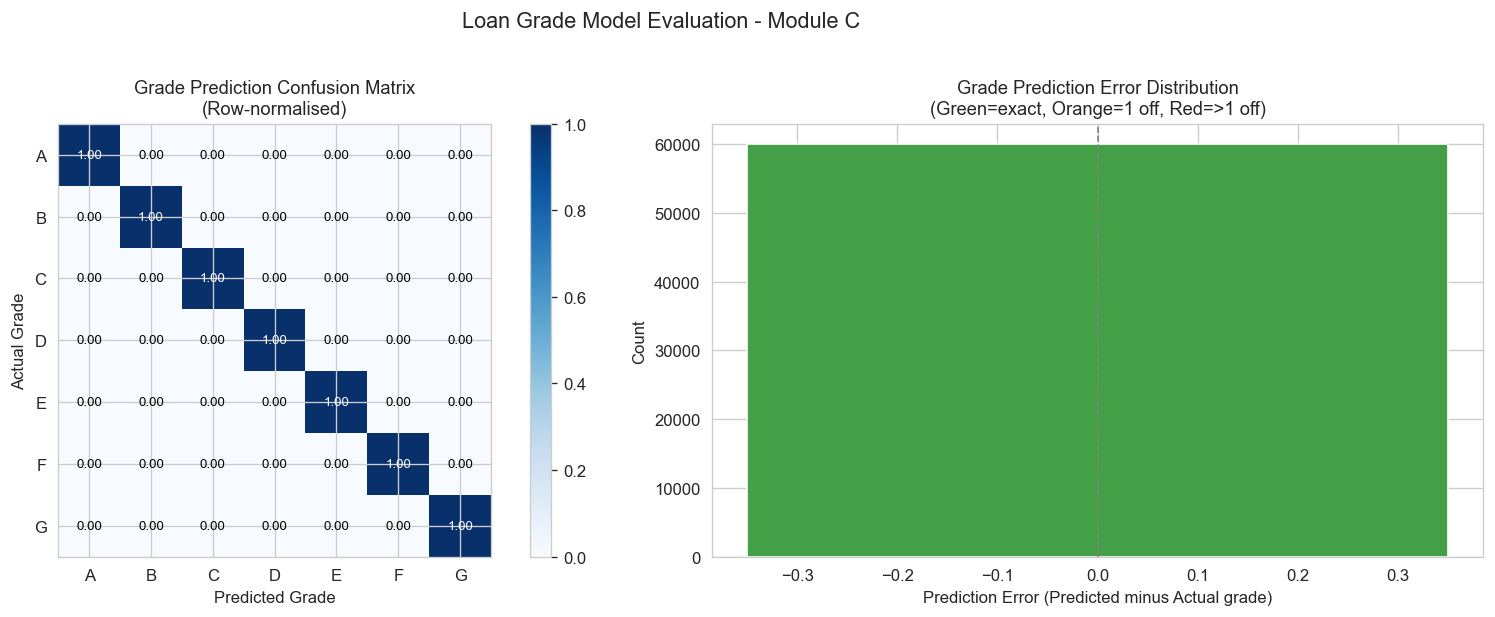

In [4]:
grade_letters = ["A","B","C","D","E","F","G"]
cm = confusion_matrix(grade_test_0, grade_pred_0)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks(range(7)); axes[0].set_yticks(range(7))
axes[0].set_xticklabels(grade_letters, fontsize=10)
axes[0].set_yticklabels(grade_letters, fontsize=10)
for i in range(7):
    for j in range(7):
        axes[0].text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                     fontsize=8, color="white" if cm_norm[i,j] > 0.5 else "black")
axes[0].set_xlabel("Predicted Grade"); axes[0].set_ylabel("Actual Grade")
axes[0].set_title("Grade Prediction Confusion Matrix\n(Row-normalised)", fontsize=11)

errors = grade_pred - grade_test
error_counts = pd.Series(errors).value_counts().sort_index()
colors_err = ["#E53935" if abs(v) > 1 else "#FB8C00" if abs(v) == 1 else "#43A047"
              for v in error_counts.index]
axes[1].bar(error_counts.index, error_counts.values, color=colors_err, edgecolor="white", width=0.7)
axes[1].axvline(0, color="gray", ls="--", lw=1)
axes[1].set_xlabel("Prediction Error (Predicted minus Actual grade)")
axes[1].set_ylabel("Count")
axes[1].set_title("Grade Prediction Error Distribution\n(Green=exact, Orange=1 off, Red=>1 off)", fontsize=11)

plt.suptitle("Loan Grade Model Evaluation - Module C", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 3. Stage 2 — Derive market_pd from Predicted Grade

The market PD is the historically observed default rate for each loan grade.
This is a direct empirical measurement from closed LendingClub loans - not a model.

In [5]:
# Build grade PD lookup from observed market data
try:
    gm = grade_meta.set_index("grade")
    grade_pd_lookup = {i+1: float(gm.loc[g,"default_rate"])
                       for i, g in enumerate("ABCDEFG") if g in gm.index}
except Exception:
    grade_pd_lookup = {1:0.054,2:0.129,3:0.224,4:0.328,5:0.432,6:0.519,7:0.564}

print("GRADE TO MARKET PD LOOKUP TABLE")
print("="*45)
for k, v in grade_pd_lookup.items():
    letter = {1:'A',2:'B',3:'C',4:'D',5:'E',6:'F',7:'G'}[k]
    print(f"  Grade {k} ({letter})  market_pd = {v:.4f} ({v*100:.2f}%)")
print("="*45)
print("\nThis is the market's revealed estimate of default risk per grade.")
print("Source: observed Charged Off rate across 1.3M closed LendingClub loans.")

# Apply to test set
grade_letter_map = {1:'A',2:'B',3:'C',4:'D',5:'E',6:'F',7:'G'}
market_pd        = np.array([grade_pd_lookup.get(int(g), 0.20) for g in grade_pred])
loan_grade_signal = np.array([grade_letter_map.get(int(g),'C') for g in grade_pred])

print(f"\nmarket_pd on test set: mean={market_pd.mean():.4f}, "
      f"min={market_pd.min():.4f}, max={market_pd.max():.4f}")


GRADE TO MARKET PD LOOKUP TABLE
  Grade 1 (A)  market_pd = 0.0548 (5.48%)
  Grade 2 (B)  market_pd = 0.1302 (13.02%)
  Grade 3 (C)  market_pd = 0.2260 (22.60%)
  Grade 4 (D)  market_pd = 0.3252 (32.52%)
  Grade 5 (E)  market_pd = 0.4220 (42.20%)
  Grade 6 (F)  market_pd = 0.5160 (51.60%)
  Grade 7 (G)  market_pd = 0.5514 (55.14%)

This is the market's revealed estimate of default risk per grade.
Source: observed Charged Off rate across 1.3M closed LendingClub loans.

market_pd on test set: mean=0.2014, min=0.0548, max=0.5514


---
## 4. Binary Default Model

Direct binary classifier for loan-level PD — used for fine-grained suggested rate computation.

In [6]:
n_pos = y_train.sum(); n_neg = (y_train==0).sum(); spw = n_neg/n_pos

xgb_default = XGBClassifier(
    n_estimators=350, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric="auc",
    random_state=42, verbosity=0,
)
xgb_default.fit(X_train, y_train, eval_set=[(X_test,y_test)], verbose=False)

pd_pred = xgb_default.predict_proba(X_test)[:,1]
auc     = roc_auc_score(y_test, pd_pred)

def ks_stat(y_true, y_score):
    df_k = pd.DataFrame({"y":y_true,"s":y_score}).sort_values("s",ascending=False)
    n_p  = df_k["y"].sum(); n_n = len(df_k)-n_p
    df_k["cp"] = df_k["y"].cumsum()/n_p
    df_k["cn"] = (1-df_k["y"]).cumsum()/n_n
    return (df_k["cp"]-df_k["cn"]).abs().max()

ks   = ks_stat(y_test.values, pd_pred)
gini = 2*auc - 1

print("BINARY DEFAULT MODEL PERFORMANCE - MODULE C")
print("="*50)
print(f"AUC  : {auc:.4f}")
print(f"KS   : {ks:.4f}")
print(f"Gini : {gini:.4f}")
print("="*50)
print("Benchmark: AUC > 0.70 | KS > 0.30 | Gini > 0.40")


BINARY DEFAULT MODEL PERFORMANCE - MODULE C
AUC  : 0.7397
KS   : 0.3517
Gini : 0.4794
Benchmark: AUC > 0.70 | KS > 0.30 | Gini > 0.40


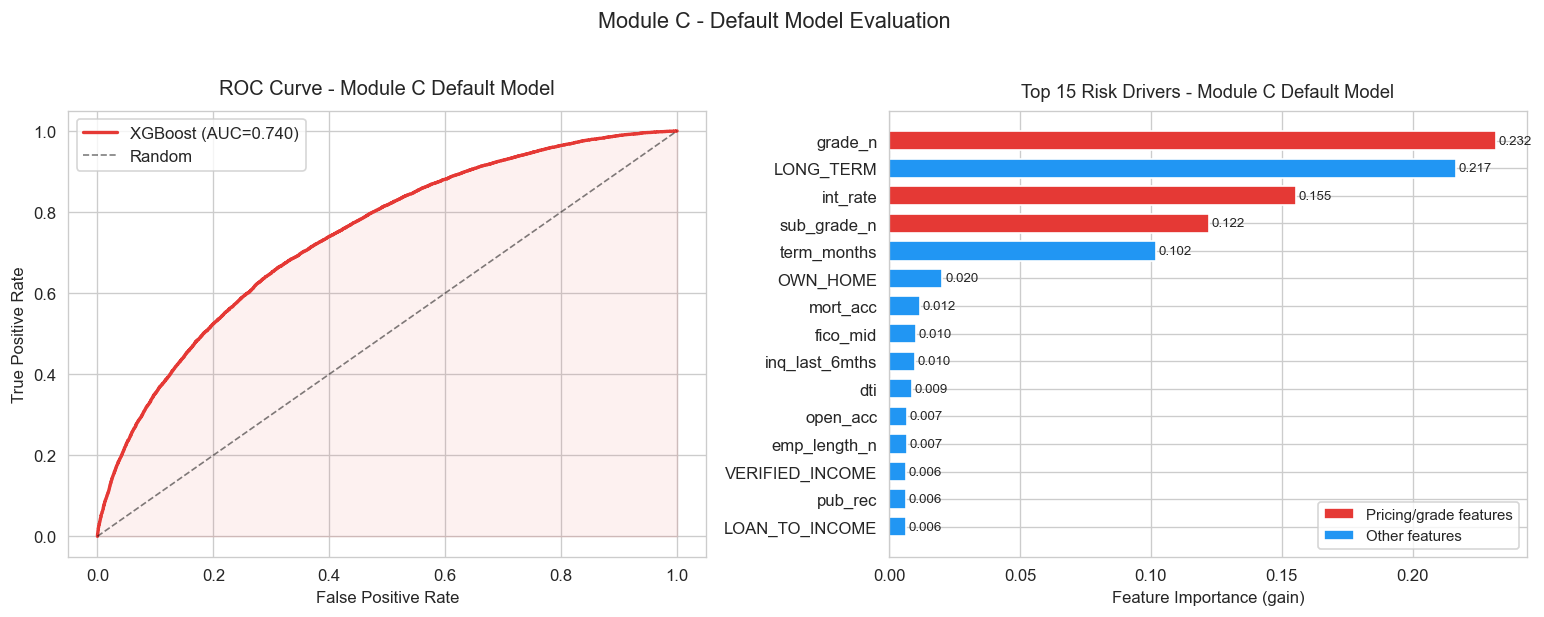

In [7]:
fpr, tpr, _ = roc_curve(y_test, pd_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color="#E53935", lw=2, label=f"XGBoost (AUC={auc:.3f})")
axes[0].plot([0,1],[0,1],"k--",lw=1,alpha=0.5,label="Random")
axes[0].fill_between(fpr, tpr, alpha=0.07, color="#E53935")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve - Module C Default Model", fontsize=12, pad=10)
axes[0].legend(fontsize=10)

importances = pd.Series(xgb_default.feature_importances_,
                         index=X_train.columns).nlargest(15).sort_values()
colors_imp = ["#E53935" if f in ["grade_n","sub_grade_n","int_rate","RATE_PER_RISK","EL_RATE_PROXY"]
               else "#2196F3" for f in importances.index]
axes[1].barh(importances.index, importances.values, color=colors_imp, edgecolor="white", height=0.7)
for i, (feat,val) in enumerate(importances.items()):
    axes[1].text(val+0.001, i, f"{val:.3f}", va="center", fontsize=8)
axes[1].set_xlabel("Feature Importance (gain)")
axes[1].set_title("Top 15 Risk Drivers - Module C Default Model", fontsize=11, pad=8)

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor="#E53935",label="Pricing/grade features"),
                          Patch(facecolor="#2196F3",label="Other features")], fontsize=9)
plt.suptitle("Module C - Default Model Evaluation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 5. Suggested Rate Model

The suggested rate answers: **what rate should this loan carry given its actual risk?**

Formula: `Suggested Rate = Grade Base Rate + Risk Adjustment`
where `Risk Adjustment = (loan_pd - grade_avg_pd) * sensitivity * 100`, capped at 5pp.

In [8]:
try:
    gm = grade_meta.set_index("grade")
    grade_rate_bands = {i+1: float(gm.loc[g,"avg_rate"])
                        for i, g in enumerate("ABCDEFG") if g in gm.index}
except Exception:
    grade_rate_bands = {1:6.87,2:9.98,3:13.25,4:16.75,5:19.20,6:23.52,7:27.15}

LGD_APPROX       = 0.40
RATE_SENSITIVITY = 0.60

def compute_suggested_rate(pred_grade, loan_pd_val, grade_pd_lkp, grade_rate_bnds):
    base_rate  = grade_rate_bnds.get(int(pred_grade), 15.0)
    grade_pd_v = grade_pd_lkp.get(int(pred_grade), 0.20)
    adjustment = (loan_pd_val - grade_pd_v) * RATE_SENSITIVITY * 100
    return round(float(base_rate + np.clip(adjustment, -5.0, 5.0)), 2)

suggested_rates = np.array([
    compute_suggested_rate(gp, lp, grade_pd_lookup, grade_rate_bands)
    for gp, lp in zip(grade_pred, pd_pred)
])

actual_rates = X_test["int_rate"].values
rate_diff    = suggested_rates - actual_rates

def pricing_adequacy(rd):
    if rd > 1.0:  return "Underpriced"
    if rd < -1.0: return "Overpriced"
    return "Fair"

pricing_labels = np.array([pricing_adequacy(rd) for rd in rate_diff])

print("PRICING ADEQUACY ANALYSIS")
print("="*60)
print(f"Underpriced (suggested > actual + 1%)  : {(rate_diff>1.0).sum():,} ({(rate_diff>1.0).mean()*100:.1f}%)")
print(f"Fairly priced (within 1%)              : {(np.abs(rate_diff)<=1.0).sum():,} ({(np.abs(rate_diff)<=1.0).mean()*100:.1f}%)")
print(f"Overpriced (suggested < actual - 1%)   : {(rate_diff<-1.0).sum():,} ({(rate_diff<-1.0).mean()*100:.1f}%)")
print()
print("VALIDATION: Pricing category vs actual defaults")
for cat in ["Underpriced","Fair","Overpriced"]:
    mask = pricing_labels == cat
    if mask.sum() > 0:
        dr = y_test[mask].mean()
        print(f"  {cat:<15}: default rate = {dr:.4f}  (n={mask.sum():,})")
print("Expected order: Underpriced > Fair > Overpriced")


PRICING ADEQUACY ANALYSIS
Underpriced (suggested > actual + 1%)  : 59,040 (98.4%)
Fairly priced (within 1%)              : 755 (1.3%)
Overpriced (suggested < actual - 1%)   : 181 (0.3%)

VALIDATION: Pricing category vs actual defaults
  Underpriced    : default rate = 0.2042  (n=59,040)
  Fair           : default rate = 0.0358  (n=755)
  Overpriced     : default rate = 0.1050  (n=181)
Expected order: Underpriced > Fair > Overpriced


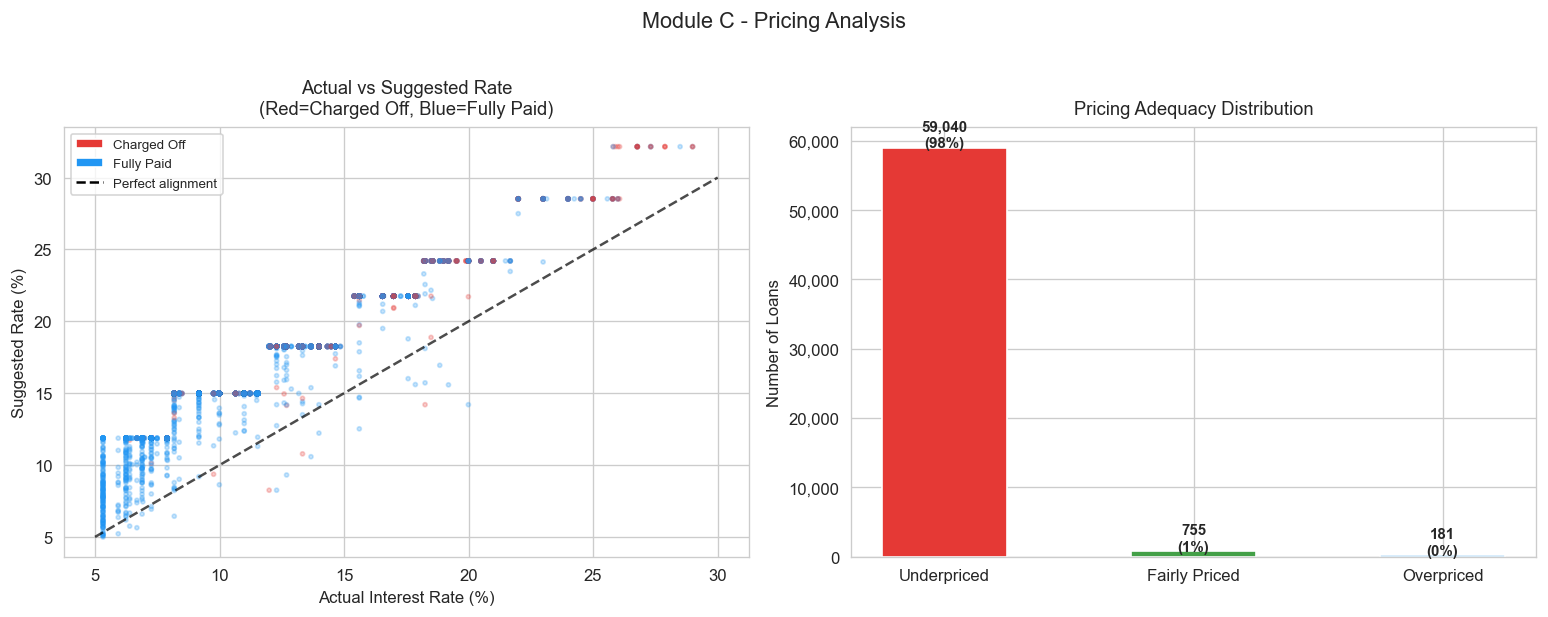

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
BLUE, RED = "#2196F3", "#E53935"

# Scatter: actual vs suggested rate
s_idx = np.random.choice(len(actual_rates), size=min(5000,len(actual_rates)), replace=False)
scatter_c = [RED if y_test.iloc[i]==1 else BLUE for i in s_idx]
axes[0].scatter(actual_rates[s_idx], suggested_rates[s_idx],
                c=scatter_c, alpha=0.25, s=6)
axes[0].plot([5,30],[5,30],"k--",lw=1.5,alpha=0.7)
axes[0].set_xlabel("Actual Interest Rate (%)"); axes[0].set_ylabel("Suggested Rate (%)")
axes[0].set_title("Actual vs Suggested Rate\n(Red=Charged Off, Blue=Fully Paid)", fontsize=11, pad=8)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
axes[0].legend(handles=[Patch(facecolor=RED,label="Charged Off"),
                          Patch(facecolor=BLUE,label="Fully Paid"),
                          Line2D([0],[0],color="black",ls="--",label="Perfect alignment")],
               fontsize=8)

cats   = ["Underpriced", "Fairly Priced", "Overpriced"]
counts = [(rate_diff>1.0).sum(), (np.abs(rate_diff)<=1.0).sum(), (rate_diff<-1.0).sum()]
colors_p = [RED, "#43A047", BLUE]
bars = axes[1].bar(cats, counts, color=colors_p, edgecolor="white", width=0.5)
for bar, cnt in zip(bars, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f"{cnt:,}\n({cnt/len(rate_diff)*100:.0f}%)",
                 ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("Pricing Adequacy Distribution", fontsize=11, pad=8)
axes[1].set_ylabel("Number of Loans")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{int(x):,}"))

plt.suptitle("Module C - Pricing Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Save Scored Output and Models

In [10]:
scored_c = X_test.copy().reset_index(drop=True)
scored_c["ACTUAL_DEFAULT"]     = y_test.values
scored_c["PREDICTED_GRADE_N"]  = grade_pred
scored_c["PREDICTED_GRADE"]    = loan_grade_signal
scored_c["MARKET_PD"]          = market_pd
scored_c["LOAN_PD"]            = pd_pred
scored_c["SUGGESTED_RATE"]     = suggested_rates
scored_c["PRICING_ADEQUACY"]   = pricing_labels
scored_c["RATE_DIFF"]          = rate_diff.round(2)
scored_c["CONCENTRATION_FLAG"] = (
    (scored_c.get("HIGH_PURPOSE_RISK", pd.Series(0, index=scored_c.index)) == 1) |
    (scored_c.get("LONG_TERM", pd.Series(0, index=scored_c.index)) == 1)
).astype(int)

scored_c.to_csv("../01_data/processed/scored_test_c.csv", index=False)
print(f"Scored output: {scored_c.shape[0]:,} rows")

with open("../03_models/xgb_grade_classifier.pkl","wb") as f:
    pickle.dump(xgb_grade, f)
with open("../03_models/xgb_default_c.pkl","wb") as f:
    pickle.dump(xgb_default, f)
with open("../03_models/grade_pd_lookup.pkl","wb") as f:
    pickle.dump({
        "grade_pd_lookup"  : grade_pd_lookup,
        "grade_rate_bands" : grade_rate_bands,
        "grade_letter_map" : grade_letter_map,
        "lgd_approx"       : LGD_APPROX,
        "rate_sensitivity" : RATE_SENSITIVITY,
    }, f)

print("Models saved:")
print("  xgb_grade_classifier.pkl | xgb_default_c.pkl | grade_pd_lookup.pkl")


Scored output: 59,976 rows
Models saved:
  xgb_grade_classifier.pkl | xgb_default_c.pkl | grade_pd_lookup.pkl


---
## 7. Module C Signal Output

### Signal Schema
```
market_pd           : float  — Market-implied P(default) from grade prediction
loan_grade_signal   : str    — Predicted LendingClub-equivalent grade (A-G)
suggested_rate      : float  — Risk-appropriate interest rate (% p.a.)
pricing_adequacy    : str    — "Underpriced" / "Fair" / "Overpriced"
concentration_flag  : bool   — High-risk purpose or 60-month term
```

### Cross-Module PD Comparison Logic (used in Decision Engine)

| Module A PD | Module C market_pd | Divergence | Interpretation |
|-------------|-------------------|------------|----------------|
| Low (<10%)  | Low (Grade A/B)   | None       | Confident approve |
| Low (<10%)  | Medium (Grade C/D)| Moderate   | Reprice recommended |
| Low (<10%)  | High (Grade E/F)  | Significant | Escalate to review |
| High (>20%) | High (Grade D/E)  | None       | Confident decline |

### Next Step
`03_portfolio_analysis_c.ipynb` builds the full concentration analysis using
rejection data and portfolio-level statistics — showing how the book's risk
profile shifts as different loan types are approved.
